# Sphere

In [ ]:
from algoritmo import new_population, sphere
import random
from utils import crossing, cut, mutation_sub

# configurações do experimento
tam_pop = 400
dimensoes = 30
min_val = -100
max_val = 100
geracoes = 1000
taxa_mutacao = 0.01  # 1% de chance para cada gene
taxa_crossing = 0.20 # 20% de chance de cruzamento

# inicializa a população inicial
new_pop = new_population(tam_pop, dimensoes, min_val, max_val)
geracoes_totais = []

for g in range(geracoes):
    fitness_list = []
    populacao_avaliada = []
    
    # 1. avaliação: calcula o fitness (objetivo: chegar em 0)
    for individuo in new_pop:
        fit = sphere(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 2. seleção por torneio
    populacao_selecionada = []
    for _ in range(tam_pop):
        # sorteia 2 e o menor fitness vence 
        a, b = random.sample(populacao_avaliada, 2)
        vencedor = a if a["fitness"] < b["fitness"] else b
        populacao_selecionada.append(vencedor)
    
    # salva o melhor fitness desta geração para usar no gráfico
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 3. criação da próxima geração (cruzamento + mutação)
    new_pop = []
    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # decide se vai haver cruzamento
        if crossing(taxa_crossing):
            filho1, filho2 = cut(pai1, pai2)
        else:
            # se não cruzar, cria clones 
            filho1, filho2 = pai1[:], pai2[:]

        # aplica a mutação por substituição
        filho1 = mutation_sub(filho1, taxa_mutacao, min_val, max_val)
        filho2 = mutation_sub(filho2, taxa_mutacao, min_val, max_val)

        new_pop.append(filho1)
        new_pop.append(filho2)

print("\n--- resultado final ---")
print(f"menor valor de sphere encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 50372.11416
Geração 2 | Melhor fitness: 48252.39921
Geração 3 | Melhor fitness: 46784.41378
Geração 4 | Melhor fitness: 44087.35223
Geração 5 | Melhor fitness: 28822.86584
Geração 6 | Melhor fitness: 27874.74808
Geração 7 | Melhor fitness: 26460.96662
Geração 8 | Melhor fitness: 25264.95703
Geração 9 | Melhor fitness: 24404.96369
Geração 10 | Melhor fitness: 19303.60366
Geração 11 | Melhor fitness: 17948.19329
Geração 12 | Melhor fitness: 17323.63728
Geração 13 | Melhor fitness: 18481.71834
Geração 14 | Melhor fitness: 19897.64953
Geração 15 | Melhor fitness: 17695.87180
Geração 16 | Melhor fitness: 17126.45380
Geração 17 | Melhor fitness: 15797.58861
Geração 18 | Melhor fitness: 12972.82776
Geração 19 | Melhor fitness: 10589.67897
Geração 20 | Melhor fitness: 10280.39783
Geração 21 | Melhor fitness: 9828.27353
Geração 22 | Melhor fitness: 8597.84650
Geração 23 | Melhor fitness: 7702.36455
Geração 24 | Melhor fitness: 6612.29278
Geração 25 | Melhor fitness: 

## Gráficos Sphere

### Gráfico de Convergência

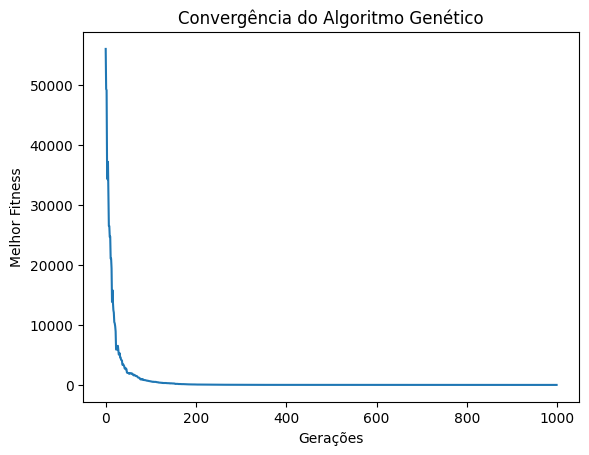

In [589]:
import matplotlib.pyplot as plt

plt.plot(geracoes_totais)

plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Melhor Fitness")

plt.show()

### Boxplot

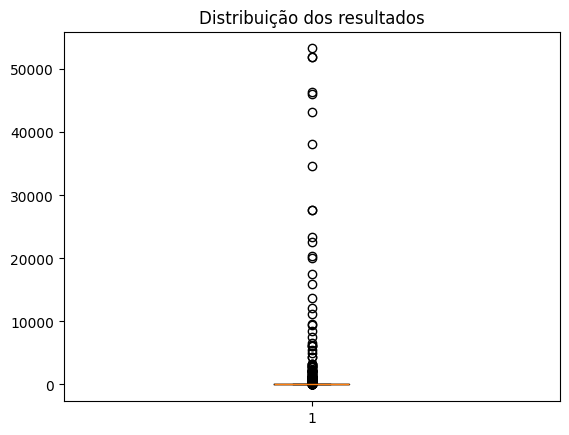

In [592]:
plt.boxplot(geracoes_totais)
plt.title("Distribuição dos resultados")
plt.show()

In [610]:
import plotly.express as px
boxplot = px.box(y=geracoes_totais, title="Boxplot Interativo")
boxplot.show()

# Rastringin




In [ ]:
from algoritmo import rastrigin

# configurações do experimento
tam_pop = 450
dimensoes = 30
min_val = -30 
max_val = 30    
geracoes = 1600
taxa_mutacao = 0.01
taxa_crossing = 0.16

# inicializa a população inicial
new_pop = new_population(tam_pop, dimensoes, min_val, max_val)
geracoes_totais = []

for g in range(geracoes):
    fitness_list = []
    populacao_avaliada = []
    
    # 1. avaliação: calcula o fitness 
    for individuo in new_pop:
        fit = rastrigin(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 2. seleção por torneio
    populacao_selecionada = []
    for _ in range(tam_pop):
        # sorteia 2 e o menor fitness vence 
        a, b = random.sample(populacao_avaliada, 2)
        vencedor = a if a["fitness"] < b["fitness"] else b
        populacao_selecionada.append(vencedor)
    
    # salva o melhor fitness desta geração
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 3. criação da próxima geração 
    new_pop = []
    for i in range(0, len(populacao_selecionada), 2):
        
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # decide se vai haver cruzamento
        if crossing(taxa_crossing):
            filho1, filho2 = cut(pai1, pai2)
        else:
            # se não cruzar, cria clones 
            filho1, filho2 = pai1[:], pai2[:]

        # aplica a mutação por substituição 
        filho1 = mutation_sub(filho1, taxa_mutacao, min_val, max_val)
        filho2 = mutation_sub(filho2, taxa_mutacao, min_val, max_val)

        new_pop.append(filho1)
        new_pop.append(filho2)

print("\n--- resultado final ---")
print(f"menor valor de rastrigin encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 5303.34701
Geração 2 | Melhor fitness: 4215.92862
Geração 3 | Melhor fitness: 4676.34275
Geração 4 | Melhor fitness: 4252.84779
Geração 5 | Melhor fitness: 3796.02534
Geração 6 | Melhor fitness: 3820.66370
Geração 7 | Melhor fitness: 3185.56805
Geração 8 | Melhor fitness: 2776.61888
Geração 9 | Melhor fitness: 2776.61888
Geração 10 | Melhor fitness: 2572.19677
Geração 11 | Melhor fitness: 1967.44338
Geração 12 | Melhor fitness: 1967.44338
Geração 13 | Melhor fitness: 1755.19175
Geração 14 | Melhor fitness: 1762.74802
Geração 15 | Melhor fitness: 1711.47243
Geração 16 | Melhor fitness: 1550.21934
Geração 17 | Melhor fitness: 1487.34004
Geração 18 | Melhor fitness: 1134.37947
Geração 19 | Melhor fitness: 1117.97798
Geração 20 | Melhor fitness: 1061.34547
Geração 21 | Melhor fitness: 1101.77835
Geração 22 | Melhor fitness: 1094.83005
Geração 23 | Melhor fitness: 912.87033
Geração 24 | Melhor fitness: 912.87033
Geração 25 | Melhor fitness: 809.61649
Geração 26 |

## Gráfico de Convergência

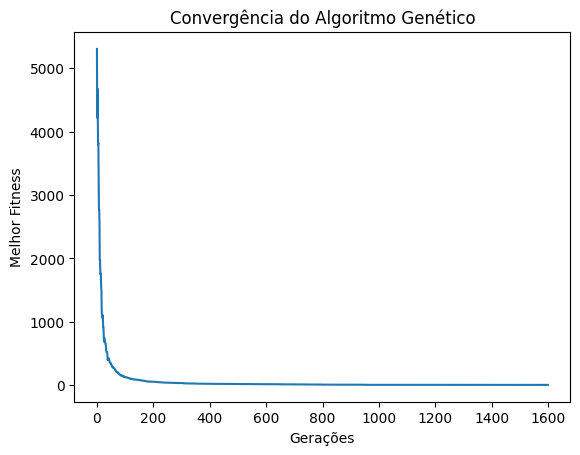

In [612]:
plt.plot(geracoes_totais)

plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Melhor Fitness")

plt.show()

## Boxplot

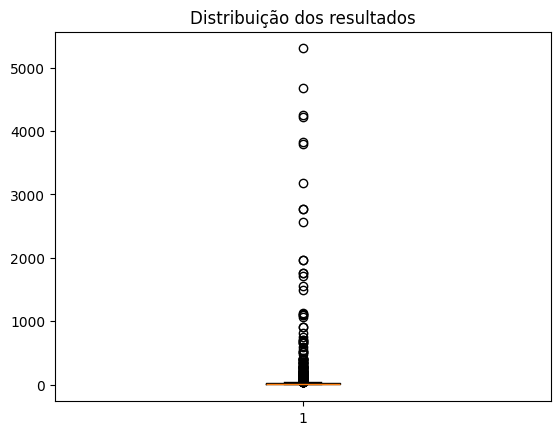

In [613]:
plt.boxplot(geracoes_totais)
plt.title("Distribuição dos resultados")
plt.show()

In [614]:
boxplot = px.box(y=geracoes_totais, title="Boxplot Interativo")
boxplot.show()

# Rosenbrock


In [619]:
from algoritmo import rosenbrock


# configurações do experimento
tam_pop = 50
dimensoes = 30
min_val = -5.12      
max_val = 5.12       
geracoes = 3000
taxa_mutacao = 0.01
taxa_crossing = 0.15

# inicializa a população inicial
new_pop = new_population(tam_pop, dimensoes, min_val, max_val)
geracoes_totais = []

for g in range(geracoes):
    fitness_list = []
    populacao_avaliada = []
    
    # 1. avaliação: calcula o fitness 
    for individuo in new_pop:
        fit = rosenbrock(individuo)
        fitness_list.append(fit)
        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fit
        })

    # 2. seleção por torneio
    populacao_selecionada = []
    for _ in range(tam_pop):
        a, b = random.sample(populacao_avaliada, 2)
        vencedor = a if a["fitness"] < b["fitness"] else b
        populacao_selecionada.append(vencedor)
    
    # salva o melhor fitness desta geração
    melhor_da_geracao = min(fitness_list)
    geracoes_totais.append(melhor_da_geracao)
    print(f"Geração {g+1} | Melhor fitness: {melhor_da_geracao:.5f}")

    # 3. criação da próxima geração 
    new_pop = []
    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]['individuo']
        pai2 = populacao_selecionada[i+1]['individuo']
        
        # decide se vai haver cruzamento
        if crossing(taxa_crossing):
            filho1, filho2 = cut(pai1, pai2)
        else:
            filho1, filho2 = pai1[:], pai2[:]

        # aplica a mutação por substituição 
        filho1 = mutation_sub(filho1, taxa_mutacao, min_val, max_val)
        filho2 = mutation_sub(filho2, taxa_mutacao, min_val, max_val)

        new_pop.append(filho1)
        new_pop.append(filho2)

print("\n--- resultado final ---")
print(f"menor valor de rosenbrock encontrado: {min(geracoes_totais)}")

Geração 1 | Melhor fitness: 209621.20503
Geração 2 | Melhor fitness: 159780.41720
Geração 3 | Melhor fitness: 121492.75916
Geração 4 | Melhor fitness: 115390.31560
Geração 5 | Melhor fitness: 56236.77371
Geração 6 | Melhor fitness: 54152.40833
Geração 7 | Melhor fitness: 52328.46837
Geração 8 | Melhor fitness: 44319.44623
Geração 9 | Melhor fitness: 46727.79660
Geração 10 | Melhor fitness: 44544.33927
Geração 11 | Melhor fitness: 39624.08423
Geração 12 | Melhor fitness: 35504.88466
Geração 13 | Melhor fitness: 35504.88466
Geração 14 | Melhor fitness: 34844.89045
Geração 15 | Melhor fitness: 30974.14199
Geração 16 | Melhor fitness: 29882.78976
Geração 17 | Melhor fitness: 26448.95900
Geração 18 | Melhor fitness: 18550.43888
Geração 19 | Melhor fitness: 18705.58466
Geração 20 | Melhor fitness: 18877.70581
Geração 21 | Melhor fitness: 17859.90367
Geração 22 | Melhor fitness: 15941.53973
Geração 23 | Melhor fitness: 15418.14933
Geração 24 | Melhor fitness: 15418.14933
Geração 25 | Melhor f

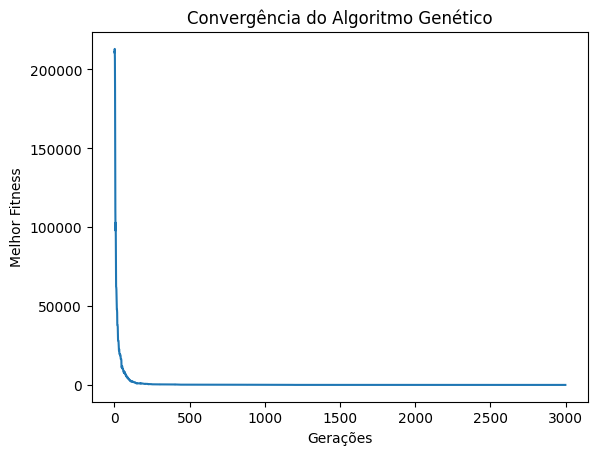

In [616]:
plt.plot(geracoes_totais)

plt.title("Convergência do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Melhor Fitness")

plt.show()

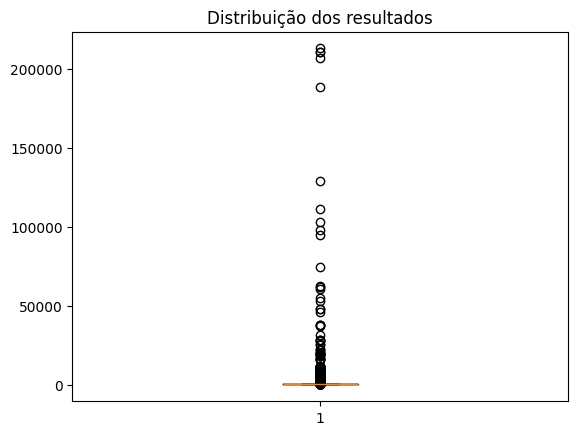

In [617]:
plt.boxplot(geracoes_totais)
plt.title("Distribuição dos resultados")
plt.show()

In [618]:
boxplot = px.box(y=geracoes_totais, title="Boxplot Interativo")
boxplot.show()